# Naive Bayes Classifiers

Given a data point $\mathbf{x} \in \R^n$ and label $y \in \R$, the probabilistic model for classification determines the label that maximises the posterior probability $p(y|\mathbf{x})$ (the conditional probability of $y$ given $\mathbf{x}$). The prediction $\hat{y}$ is given by
$$\hat{y} = \text{argmax}_y \; p(y|\mathbf{x})$$
Using Bayes' theorem theorem, this can be written as
$$\hat{y} = \text{argmax}_y \; \frac{p(\mathbf{x}|y)\:p(y)}{p(\mathbf{x})}$$
When comparing the different values of $y$ to find which one maximises $p(y|\mathbf{x})$, the denominator $p(\mathbf{x})$ remains constant. Therefore, the classification rule becomes
$$\hat{y} = \text{argmax}_y \; p(\mathbf{x}|y)\:p(y) \tag{1}$$
Remembering that $\mathbf{x}$ has $n$ features, we can write the numerator as
$$p(\mathbf{x}|y)p(y) = p(x_1,x_2,...,x_n|y)\:p(y)$$
where $x_i$ is the $i'\text{th}$ feature of $\textbf{x}$.

If the number of features, n, is large or a feature can take on a large number of values, a serious problem arises; it becomes extremely expensive and perhaps even unfeasible to compute $p(x_1,x_2,...,x_n|y)$. For example, if there were 20 binary features we would have $2^{20}$ values in the distribution $p(x_1,x_2,...,x_d|y)$.

Using the chain rule of probability we can write $p(x_1,x_2,...,x_n|y)$ as
$$p(x_1,x_2,...,x_n|y) = p(x_1|x_2,...,x_n,y)\:p(x_2|x_3,...,x_n,y)...p(x_{n-1}|x_n,y)\:p(x_n|y) \tag{2}$$
Now we make the naive assumption that gives the algorithm its name; we assume that all the features in $\mathbf{x}$ are mutually independent, conditional on $y$. If $A$ and $B$ are conditionally independent, given C, then
$$P(A|B,C)=P(A|C)$$

Therefore, from $(2)$ we can write
$$\begin{align}p(x_1,x_2,...,x_n|y)&=p(x_1|y)\:p(x_2|y)...p(x_{n-1}|y)\:p(x_n|y) \notag\\
&=\prod^n_{i=1} p(x_i|y) \notag
\end{align}$$

Substituting into $(1)$ the classification rule becomes
$$\hat{y} = \text{argmax}_y \; p(y)\:\prod^n_{i=1} p(x_i|y) \tag{3}$$
Since we now have a product of one-dimensional proabilities, we only need to know $C\times n$ parameters instead of $C^n$. Returning to the example above of 20 binary features, after the naive Bayes assumption we would only require 400 parameters.

When working with continuous data, we often assume that it is normally distributed. In this case we will make the assumption that each feature is normally distributed for a given class. That is
$$p(x_i|y)=\frac{1}{\sqrt{2\pi}}\sigma_{iy}\exp\Bigg[{\frac{-(x_i-\mu_{iy})^2}{2\sigma_{iy}^2}}\Bigg ]$$
where $\mu_{iy}$ and $\sigma_{iy}$ are the mean and standard deviation, respectively, of the $i$'th feature for class $y$.

The classification rule is then
$$\hat{y} = \text{argmax}_y \; p(y)\:\prod^n_{i=1}\frac{1}{\sqrt{2\pi}\sigma_{iy}}\exp\Bigg[{\frac{-(x_i-\mu_{iy})^2}{2\sigma_{iy}^2}}\Bigg ]$$
The natural logarithm is a strictly increasing function which means that if $b>a$ then $\ln b>\ln a$.
Consequently, we can replace the classification rule with its natural log and reach the same result. We do this for numerical stability and to speed up the calculation:
$$\begin{align}\hat{y} &= \text{argmax}_y \; \ln p(y)\: + \ln\left\{\prod^n_{i=1}\frac{1}{\sqrt{2\pi}\sigma_{iy}}\exp\Bigg[{\frac{-(x_i-\mu_{iy})^2}{2\sigma_{iy}^2}}\Bigg ]\right\}\notag{}\\
&= \text{argmax}_y \; \ln p(y)\: + \sum^n_{i=1}\ln\left\{\frac{1}{\sqrt{2\pi}\sigma_{iy}}\exp\Bigg[{\frac{-(x_i-\mu_{iy})^2}{2\sigma_{iy}^2}}\Bigg ]\right\}\notag{}\\
&= \text{argmax}_y \; \ln p(y)\: + \sum^n_{i=1}\left\{\ln\Bigg (\frac{1}{\sqrt{2\pi}\sigma_{iy}}\Bigg ) + \ln\Bigg(\exp\Bigg[{\frac{-(x_i-\mu_{iy})^2}{2\sigma_{iy}^2}}\Bigg ]\Bigg )\right\}\notag{}\\
&= \text{argmax}_y \; \ln p(y)\: - \sum^n_{i=1}\left[\ln\left(\sqrt{2\pi}\right)+\ln\left(\sigma_{iy}\right)+{\frac{(x_i-\mu_{iy})^2}{2\sigma_{iy}^2}}\right] \notag{}
\end{align}$$
Ignoring the first term in the sum which is constant for all classes, we finally arrive at
$$\hat{y} = \text{argmax}_y \; \ln p(y)\: - \sum^n_{i=1}\left[\ln\left(\sigma_{iy}\right)+{\frac{(x_i-\mu_{iy})^2}{2\sigma_{iy}^2}}\right]\tag{4}$$

In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Load in the data and split into training and testing sets.

In [2]:
data = load_wine(as_frame=True)
X = data['data']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)

Let's review the correlation between features, and the feature distributions for each of the three classes in the training data.

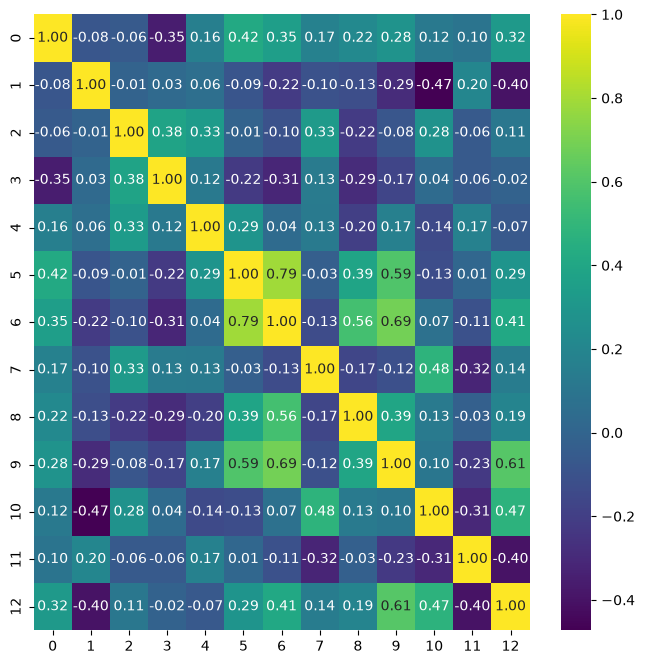

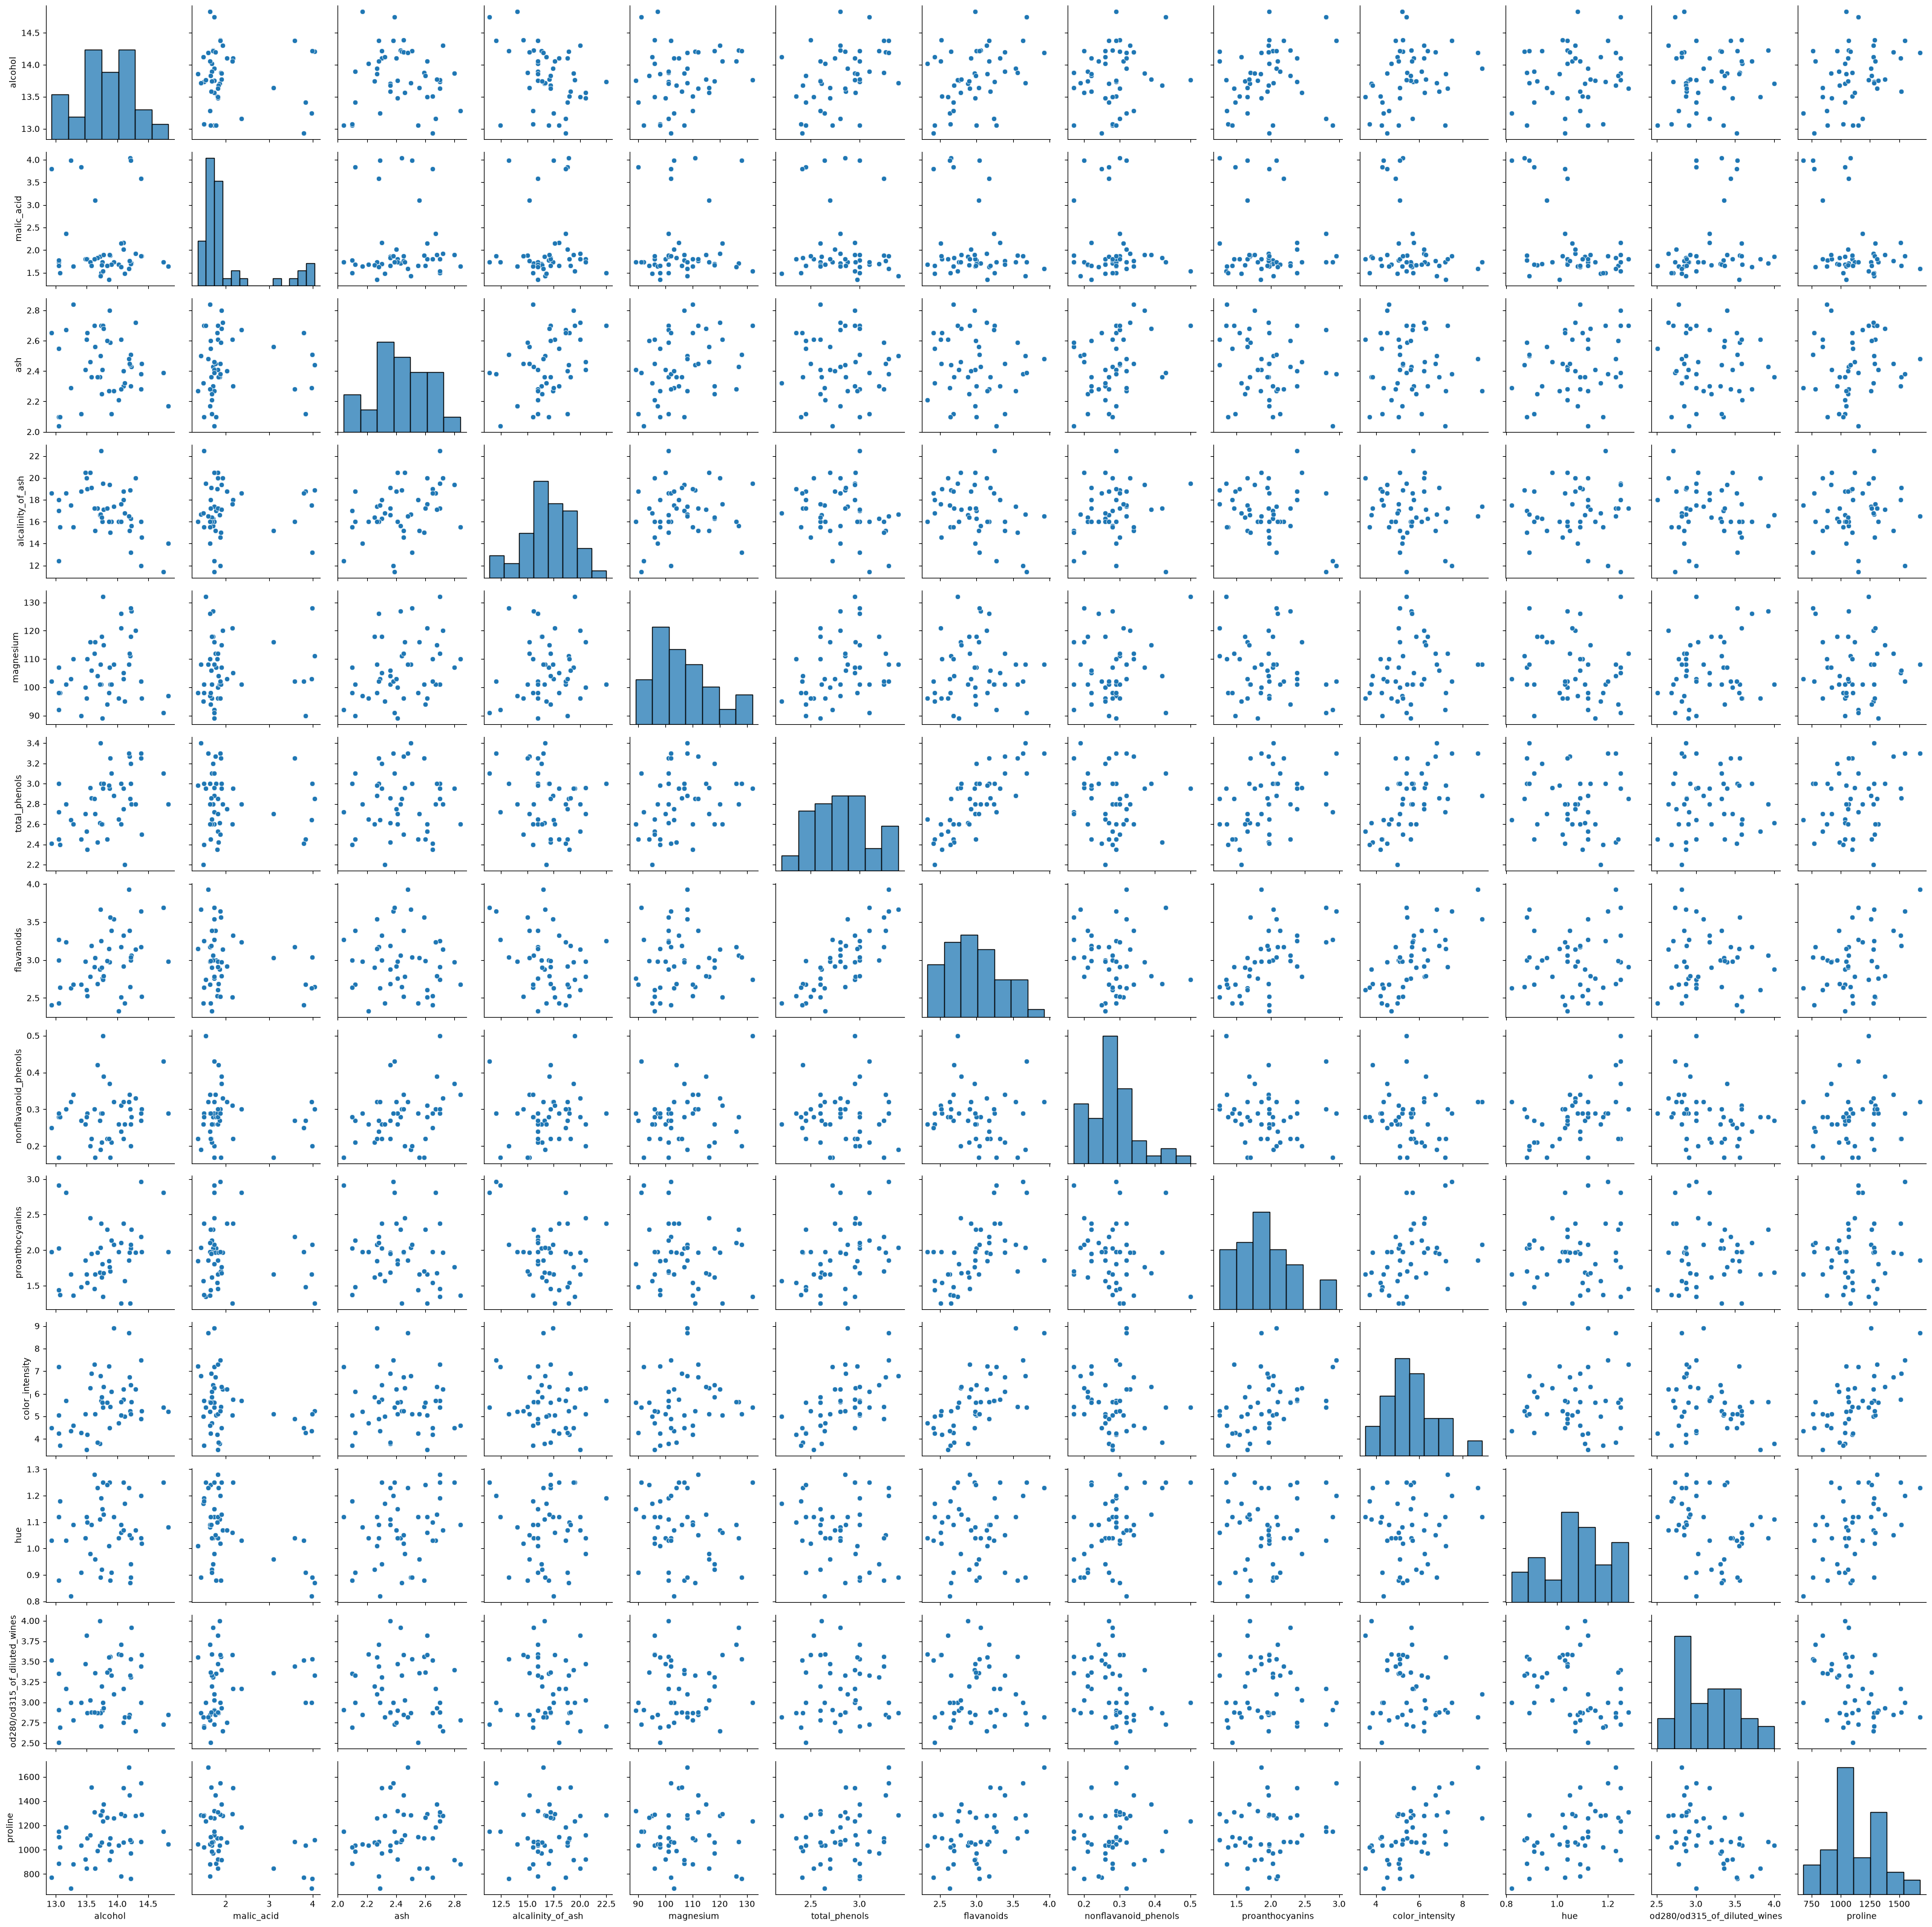

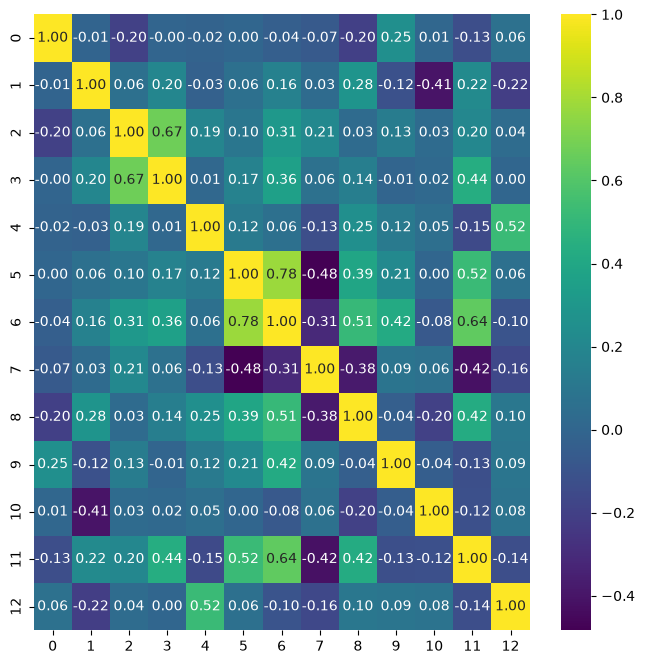

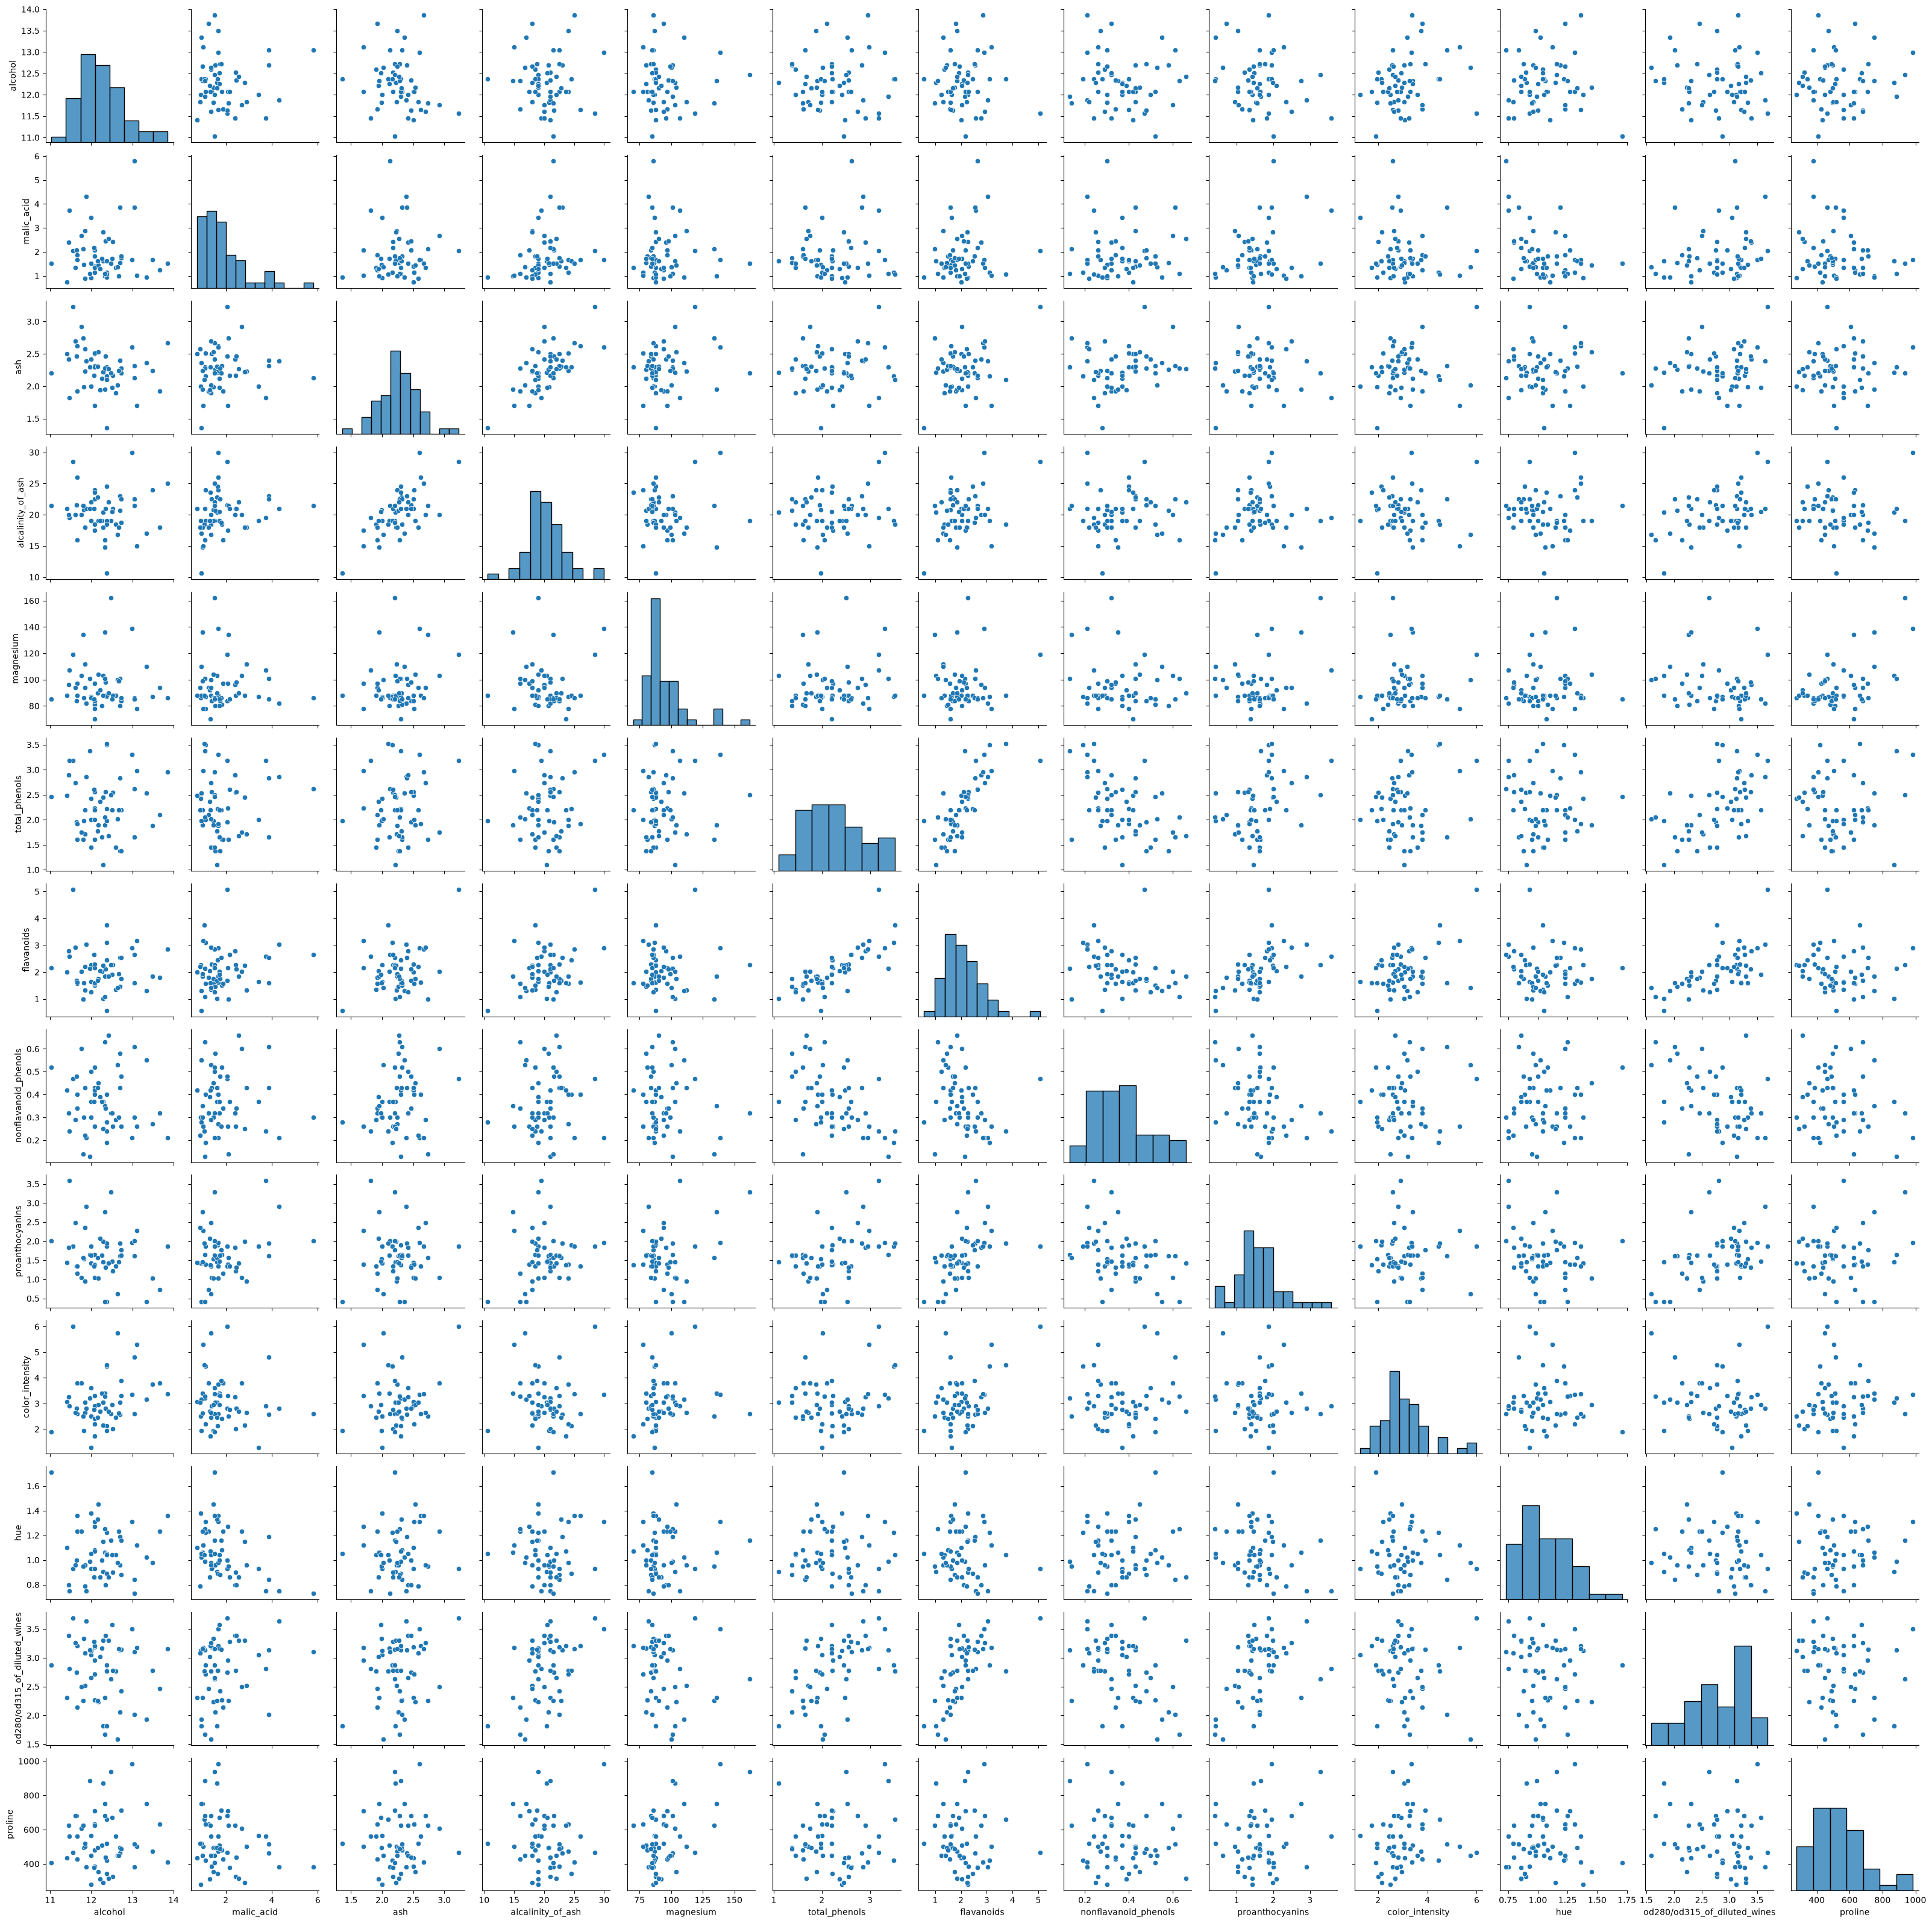

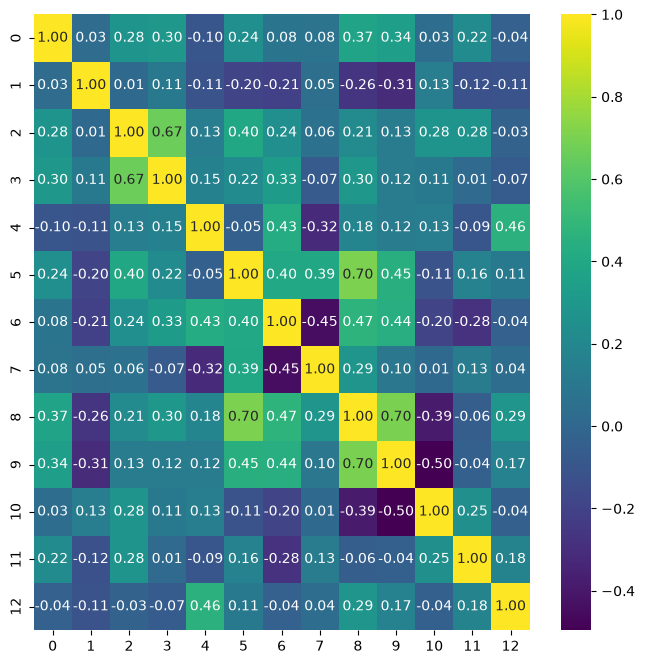

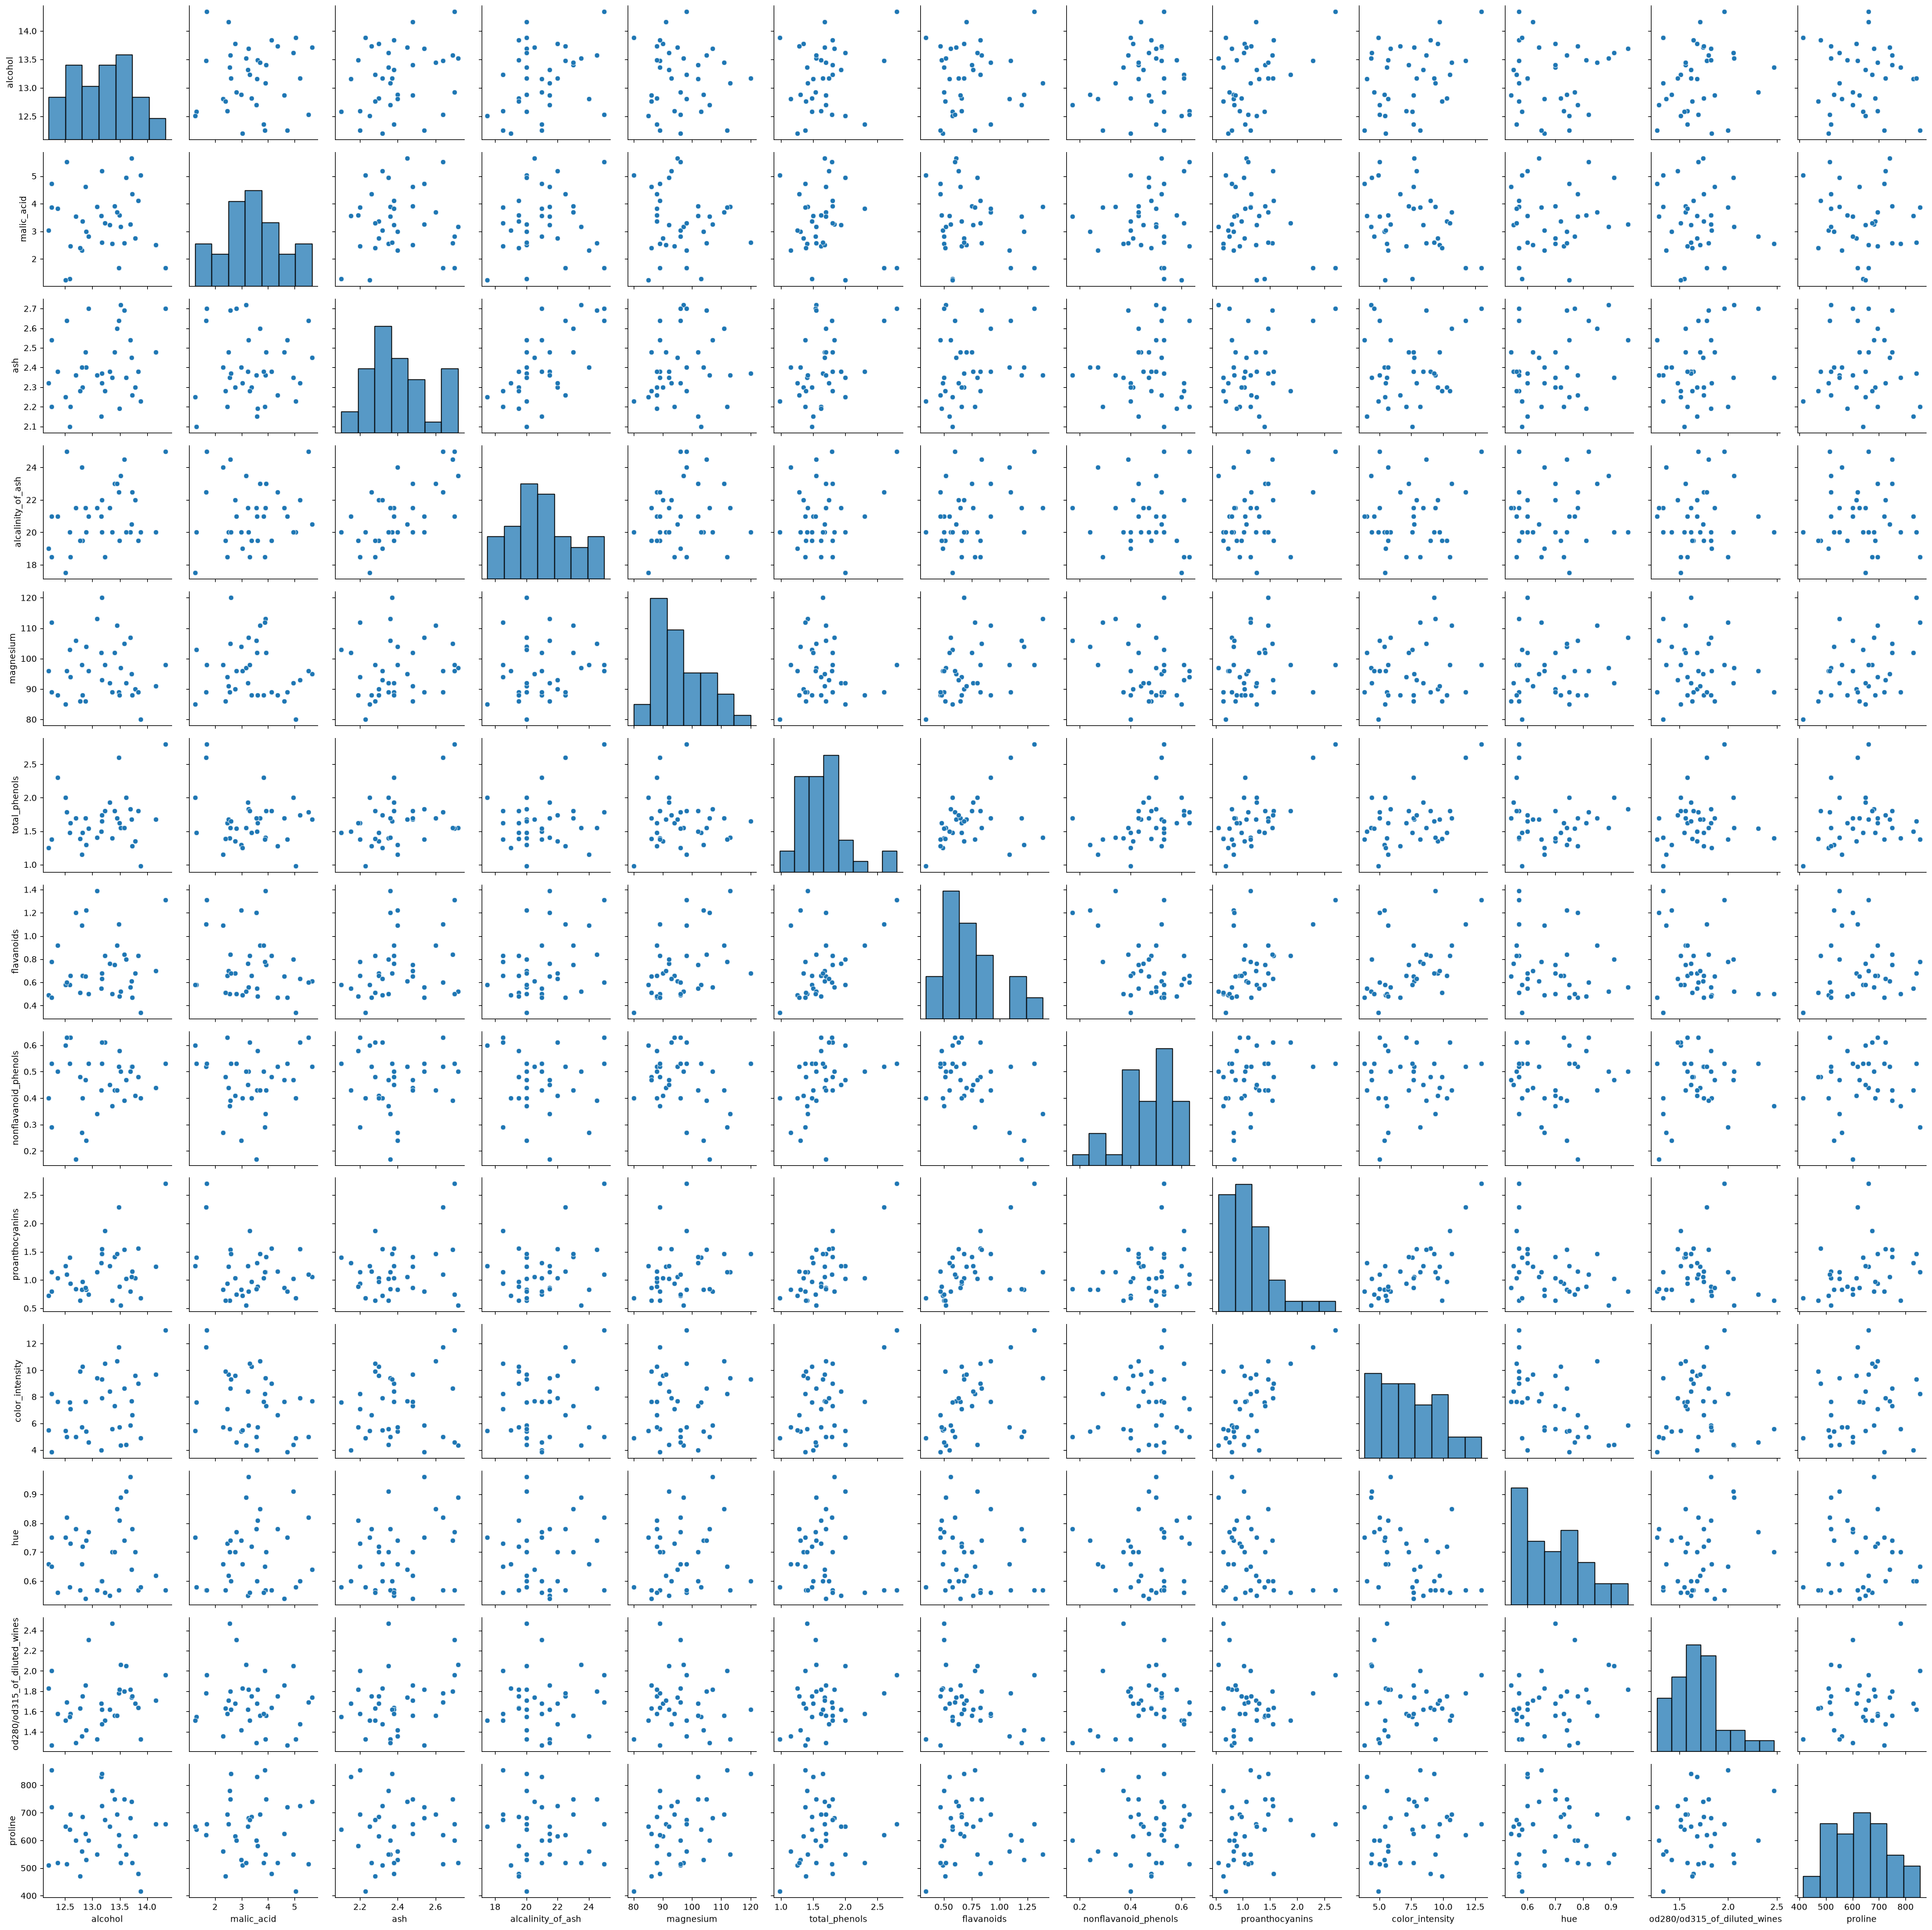

In [3]:
def class_corr_dist(X_train, y_train):

    X_train["target"] = y_train
    y_vals = list(set(y_train))
    # for each class
    for y in y_vals:
        filtered = X_train[X_train["target"] == y]
        filtered = filtered.drop("target", axis=1)
        corr_matrix = filtered.corr().values
        plt.figure(figsize=(8, 8))
        img = sns.heatmap(corr_matrix, cmap="viridis", annot=True, fmt=".2f")

        g = sns.PairGrid(filtered)
        g.map_diag(sns.histplot)
        g.map_offdiag(sns.scatterplot)
        plt.show()

class_corr_dist(X_train, y_train)

We can see that there are strong correlations between some of the features, so the naive Bayes assumption that the features are conditionally independent given the class is false in this dataset. However, we will see that, as if often the case, the naive Bayes algorithm performs well nevertheless. Although not perfectly normally distributed, we are happy that the features could well be approximated by the normal distribution with a larger sample size. Therefore, we will proceed with the Gaussian naive Bayes approach.

The functions below compute the classification rule $(4)$. The prior probability $p(y)$ is calculated by finding the relative frequency of $y$ in the training data. For example, if $y$ appears on $41$ occasions in a training set of $100$ examples, then $p(y)=0.41$.

In [4]:
def prior_distribution(y_train):

    val_counts = y_train.value_counts()
    prior_dist = val_counts.to_dict()

    return prior_dist


def training_data_stats(X_train, y_train):

    means = {}
    std_devs = {}

    X_train["target"] = y_train
    y_vals = list(set(y_train))
    # for each class
    for y in y_vals:
        filtered = X_train[X_train["target"] == y]
        filtered = filtered.drop("target", axis=1)
        # for each feature
        columns = filtered.columns
        means[y] = [filtered[col].mean().item() for col in columns]
        std_devs[y] = [filtered[col].std().item() for col in columns]

    return means, std_devs


def posterior_dist(X_train, y_train, x):

    means, std_devs = training_data_stats(X_train, y_train)
    prior_dist = prior_distribution(y_train)

    post_dist = {}
    y_vals = list(set(y_train))
    # for each class
    for y in y_vals:

        means_y = means[y]
        std_devs_y = std_devs[y]
        second_term = 0

        for i in range(len(x)):
           
            std_dev = std_devs_y[i]
            mean = means_y[i]
            second_term += np.log(std_dev) + (x[i] - mean)**2 / (2*std_dev**2)
        # classification rule (4)    
        post_dist[y] = (np.log(prior_dist[y]) - second_term).item()

    return post_dist


For each test data example we make a prediction. Subsequently, we calculate the accuracy of all of our predictions.

In [5]:
y_pred = []
for i in range(len(y_test)):
    x = X_test.iloc[i].tolist()
    post_dist = posterior_dist(X_train, y_train, x )
    prediction = max(post_dist, key=post_dist.get)
    y_pred.append(prediction)

accuracy_score(y_test, y_pred)

0.9722222222222222

Although the conditional independence requirement was not satisfied, the model still achieved an impressive accuracy score of over 97%.